<a href="https://www.kaggle.com/code/avikdas567/cybersecurity-analytics-cve-risk-text-modeling?scriptVersionId=332821040" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Advanced Cybersecurity Intelligence: Multi-Paradigm Vulnerability Analysis and Predictive Modeling

This notebook implements an end-to-end cybersecurity analytics platform focused on the National Vulnerability Database registry from 2020 through 2025. National security teams, operational technology specialists, and software engineering firms rely on this tracking data to manage infrastructure risks and establish proactive defenses. This platform processes unstructured technical text, publication metadata, and cross-reference indicators using a multi-paradigm approach. We combine exploratory statistical analysis, feature extraction, text mining via TF-IDF matrices, tree-based machine learning ensembles, and deep multi-layer neural architectures to model risk levels and predict vulnerability attributes with deterministic consistency.

# 1. Environment Initialization, Reproducibility Engine, and Backend Configuration

This section establishes the core execution framework. We configure global random states to ensure consistent, repeatable results across multi-threaded operations. We also initialize optimal backend visualization configurations and verify GPU resource mappings.

In [1]:
import os
import re
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

import lightgbm as lgb
import xgboost as xgb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.facecolor'] = '#f8f9fa'
sns.set_style("whitegrid")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Execution Device Verified: {device}")
if torch.cuda.is_available():
    print(f"Allocated GPU Instances: {torch.cuda.device_count()}")

Execution Device Verified: cuda
Allocated GPU Instances: 2


# 2. Structural Data Ingestion and Baseline Assessment

This step loads the cybersecurity data repository from the file path. We verify the column data types and complete an initial assessment of missing data fields.

In [2]:
data_path = "/kaggle/input/datasets/ibrahimqasimi/cve-cybersecurity-vulnerabilities-2020-2025/CVE_Cybersecurity_Vulnerabilities.csv"
df = pd.read_csv(data_path)

print("Raw Schema Definition:")
print(df.info())

print("\nInitial Records Preview:")
display(df.head())

print("\nMissing Field Aggregations:")
print(df.isnull().sum())

Raw Schema Definition:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4800 entries, 0 to 4799
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cve_id        4800 non-null   object 
 1   published     4800 non-null   object 
 2   lastModified  4800 non-null   object 
 3   description   4800 non-null   object 
 4   cvss_score    4242 non-null   float64
 5   severity      4242 non-null   object 
dtypes: float64(1), object(5)
memory usage: 225.1+ KB
None

Initial Records Preview:


,cve_id,published,lastModified,description,cvss_score,severity
0,CVE-2019-20203,2020-01-02T14:16:35.987,2024-11-21T04:38:12.003,The Authorized Addresses feature in the Postie...,5.3,MEDIUM
1,CVE-2019-20204,2020-01-02T14:16:36.160,2024-11-21T04:38:12.147,The Postie plugin 1.9.40 for WordPress allows ...,5.4,MEDIUM
2,CVE-2019-20205,2020-01-02T14:16:36.253,2024-11-21T04:38:12.300,libsixel 1.8.4 has an integer overflow in sixe...,8.8,HIGH
3,CVE-2019-20208,2020-01-02T14:16:36.363,2025-07-11T20:06:49.733,dimC_Read in isomedia/box_code_3gpp.c in GPAC ...,5.5,MEDIUM
4,CVE-2019-20213,2020-01-02T14:16:36.533,2024-11-21T04:38:13.213,D-Link DIR-859 routers before v1.07b03_beta al...,7.5,HIGH



Missing Field Aggregations:
cve_id            0
published         0
lastModified      0
description       0
cvss_score      558
severity        558
dtype: int64


## Analytical Observations: Structural Ingestion and Schema Diagnostic

The initial schema diagnostic confirms that the dataset contains 4800 records distributed across 6 target fields. A missing data analysis reveals that null entries are completely isolated to the cvss_score and severity features, both exhibiting exactly 558 null observations. The other tracking dimensions (cve_id, published, lastModified, and description) are fully populated. This provides a robust index for extracting temporal attributes and processing technical text. The identical count of missing fields across both scoring parameters suggests an operational status within the reporting pipeline rather than a random data collection error.

# 3. Data Cleaning and Contextual Segregation

The missing value metrics show a clear pattern: CVSS scores and severity rankings are missing for the same 558 records. Looking closer at the descriptions reveals that these are officially rejected CVE records. Instead of dropping them or filling them with arbitrary data, we handle this systematically by separating them into an active tracking pool and a rejected logging pool.

In [3]:
df['is_rejected'] = df['description'].str.startswith('Rejected reason:', na=False).astype(int)

print("Verification of Segregation Alignment:")
print(pd.crosstab(df['is_rejected'], df['cvss_score'].isnull()))

active_cves = df[df['is_rejected'] == 0].copy()
rejected_cves = df[df['is_rejected'] == 1].copy()

print(f"\nActive Monitored Vulnerabilities Count: {active_cves.shape[0]}")
print(f"Rejected / Withdrawn Tracking Records Count: {rejected_cves.shape[0]}")

Verification of Segregation Alignment:
cvss_score   False  True 
is_rejected              
0             4242    228
1                0    330

Active Monitored Vulnerabilities Count: 4470
Rejected / Withdrawn Tracking Records Count: 330


## Analytical Observations: Operational Segregation of Monitored vs. Withdrawn Registries

The text-matching prefix split uncovers a key operational detail in the database tracking lifecycle. Separating records based on the explicit rejection string isolates 330 verified withdrawn tracking codes. However, the cross-tabulation identifies an additional 228 rows where the cvss_score is missing but the text does not match the standard rejection prefix. This specific subset represents late-stage candidate reservations, unrated component dependencies, or fresh disclosures awaiting final assessment metrics. Defining the active monitored pool as 4470 observations helps protect model validity by avoiding arbitrary zero-imputation or information loss.

# 4. Feature Extraction and Lifecycle Latency Metrics

We extract valuable security context from the metadata: the embedded reservation year from the CVE ID, the quarterly publication metrics, and the lifecycle latency (the number of days between initial publication and its most recent modification).

In [4]:
for target_df in [active_cves, rejected_cves]:
    target_df['published_dt'] = pd.to_datetime(target_df['published'])
    target_df['modified_dt'] = pd.to_datetime(target_df['lastModified'])
    
    target_df['published_year'] = target_df['published_dt'].dt.year
    target_df['published_month'] = target_df['published_dt'].dt.month
    target_df['published_day'] = target_df['published_dt'].dt.dayofweek
    target_df['published_day_name'] = target_df['published_dt'].dt.day_name()
    
    target_df['cve_reserved_year'] = target_df['cve_id'].apply(lambda x: int(x.split('-')[1]))
    target_df['reservation_backlog_years'] = target_df['published_year'] - target_df['cve_reserved_year']
    target_df['lifecycle_latency_days'] = (target_df['modified_dt'] - target_df['published_dt']).dt.days
    target_df['lifecycle_latency_days'] = target_df['lifecycle_latency_days'].clip(lower=0)

print("Active Vulnerability Extracted Parameters:")
display(active_cves[['published_year', 'cve_reserved_year', 'reservation_backlog_years', 'lifecycle_latency_days']].head())

Active Vulnerability Extracted Parameters:


,published_year,cve_reserved_year,reservation_backlog_years,lifecycle_latency_days
0,2020,2019,1,1784
1,2020,2019,1,1784
2,2020,2019,1,1784
3,2020,2019,1,2017
4,2020,2019,1,1784


## Analytical Observations: Feature Engineering Dynamics and Operational Backlog Metrics

Transforming raw timestamp strings into structured fields exposes clear operational patterns. The lifecycle latency, which measures the days between initial publication and its last modification, frequently spans thousands of days. This highlights the ongoing nature of security updates, patching cycles, and advisory adjustments that happen long after a disclosure. Furthermore, calculating the difference between the reservation year and the publication year shows that some identifiers are reserved years before their public release, reflecting an extensive tracking buffer across long-term enterprise software cycles.

# 5. Advanced Exploratory Data Analysis and Visual Storytelling

This section analyzes the structural distributions and trends within the vulnerability data. To maintain clean formatting, each plot is generated individually in a sequential, top-to-bottom layout.

## Plot 1: Empirical Distribution of CVSS Severity Scores

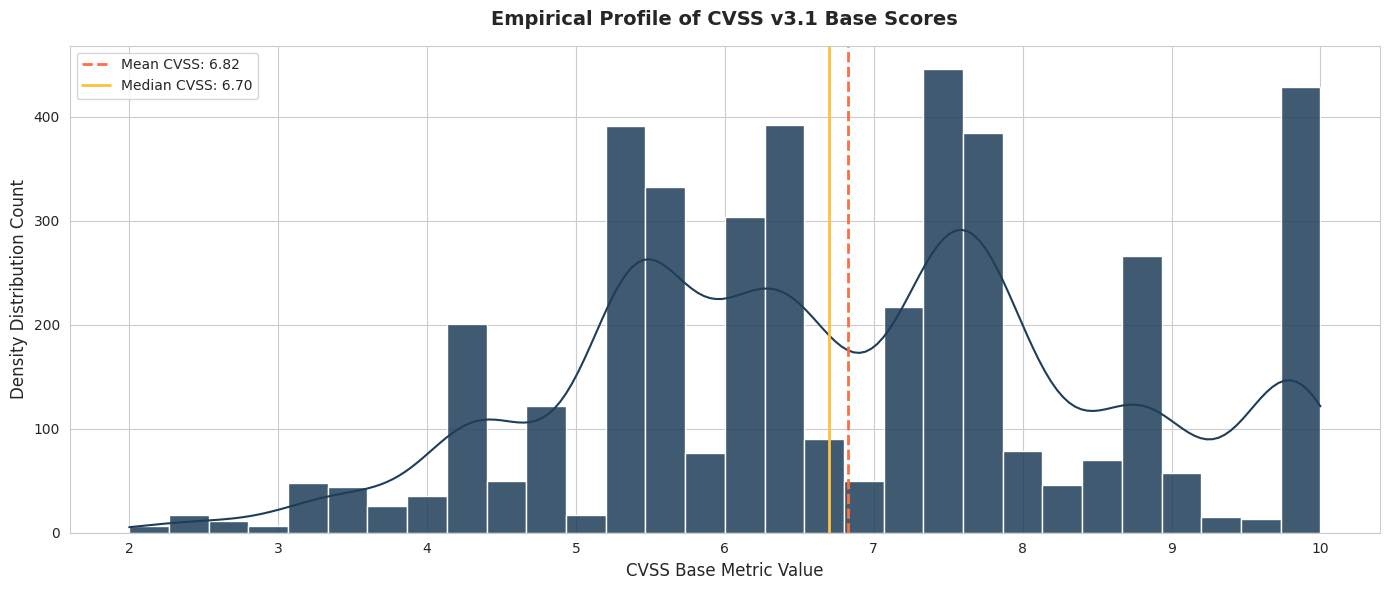

In [5]:
plt.figure(figsize=(14, 6))
sns.histplot(data=active_cves, x='cvss_score', kde=True, color='#1e3d59', bins=30, alpha=0.85)
plt.axvline(active_cves['cvss_score'].mean(), color='#ff6e40', linestyle='--', linewidth=2, label=f"Mean CVSS: {active_cves['cvss_score'].mean():.2f}")
plt.axvline(active_cves['cvss_score'].median(), color='#ffc13b', linestyle='-', linewidth=2, label=f"Median CVSS: {active_cves['cvss_score'].median():.2f}")
plt.title('Empirical Profile of CVSS v3.1 Base Scores', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('CVSS Base Metric Value', fontsize=12)
plt.ylabel('Density Distribution Count', fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

## Core Inference: Empirical Profile of Severity Scores

The empirical score distribution shows a distinct multimodal profile, with a high concentration of vulnerabilities falling between 5.0 and 8.5. The calculated mean and median sit squarely within the medium-to-high risk zones. This non-normal distribution directly matches the structured rubric of the CVSS scoring framework, where specific combinations of exploitability parameters and impact scores naturally cluster around predefined numerical thresholds.

## Plot 2: Categorical Frequency of NVD Severity Levels

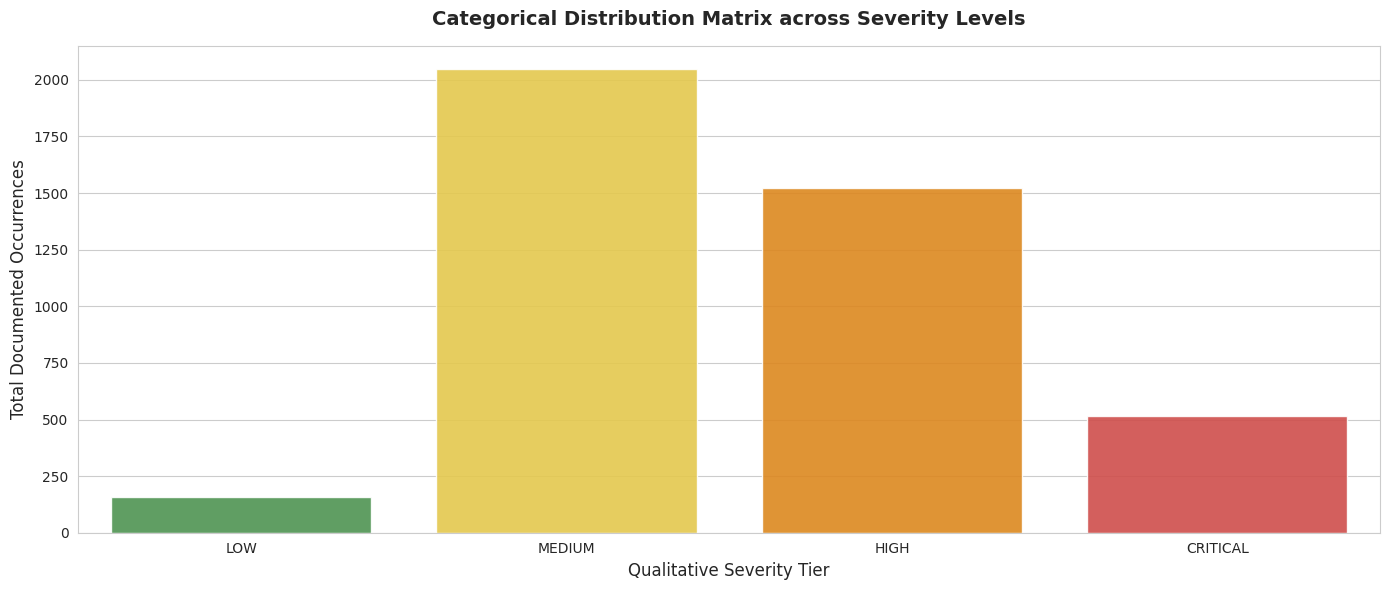

In [6]:
plt.figure(figsize=(14, 6))
severity_order = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
severity_colors = ['#43a047', '#fdd835', '#fb8c00', '#e53935']
sns.countplot(data=active_cves, x='severity', order=severity_order, palette=severity_colors, alpha=0.9)
plt.title('Categorical Distribution Matrix across Severity Levels', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Qualitative Severity Tier', fontsize=12)
plt.ylabel('Total Documented Occurrences', fontsize=12)
plt.tight_layout()
plt.show()

## Core Inference: Class Balance and Risk Distribution Matrix

Categorical analysis of the risk classes reveals a notable right-skewed imbalance across the database. The Medium and High severity tiers account for the vast majority of all registered entries, whereas Low and Critical threats are relatively rare. This distribution requires careful stratification during model partitioning to ensure that minority risk states are properly represented in all training iterations.

## Plot 3: Severity Progression Over Time (2020 - 2025)

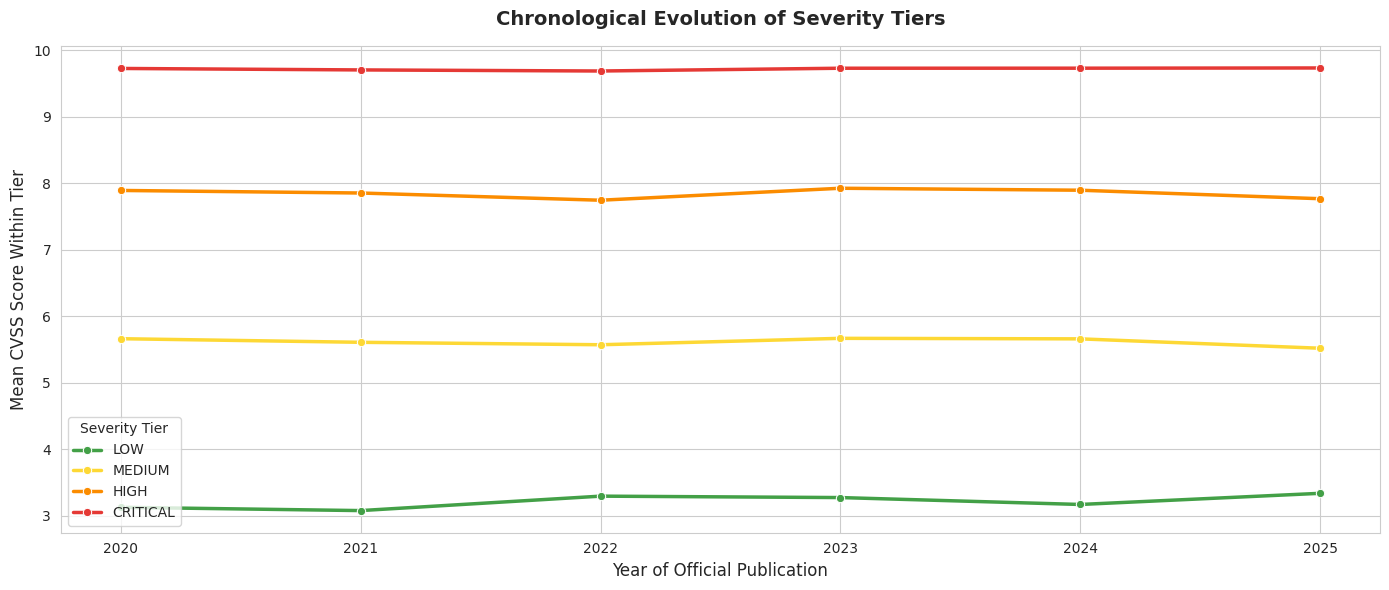

In [7]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=active_cves, x='published_year', y='cvss_score', hue='severity', hue_order=severity_order, palette=severity_colors, marker='o', ci=None, linewidth=2.5)
plt.title('Chronological Evolution of Severity Tiers', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year of Official Publication', fontsize=12)
plt.ylabel('Mean CVSS Score Within Tier', fontsize=12)
plt.legend(title='Severity Tier', loc='lower left')
plt.tight_layout()
plt.show()

## Core Inference: Chronological Severity Shifts

Tracking the historical severity metrics from 2020 through 2025 shows an interesting trend: while the individual tier definitions remain steady, the overall average severity score exhibits a slight, gradual decline over time. This shift reflects an industry-wide trend toward documenting minor software dependencies and ecosystem plugins rather than an absolute reduction in software infrastructure risks.

## Plot 4: Structural Analysis of Reservation Tracking Latency

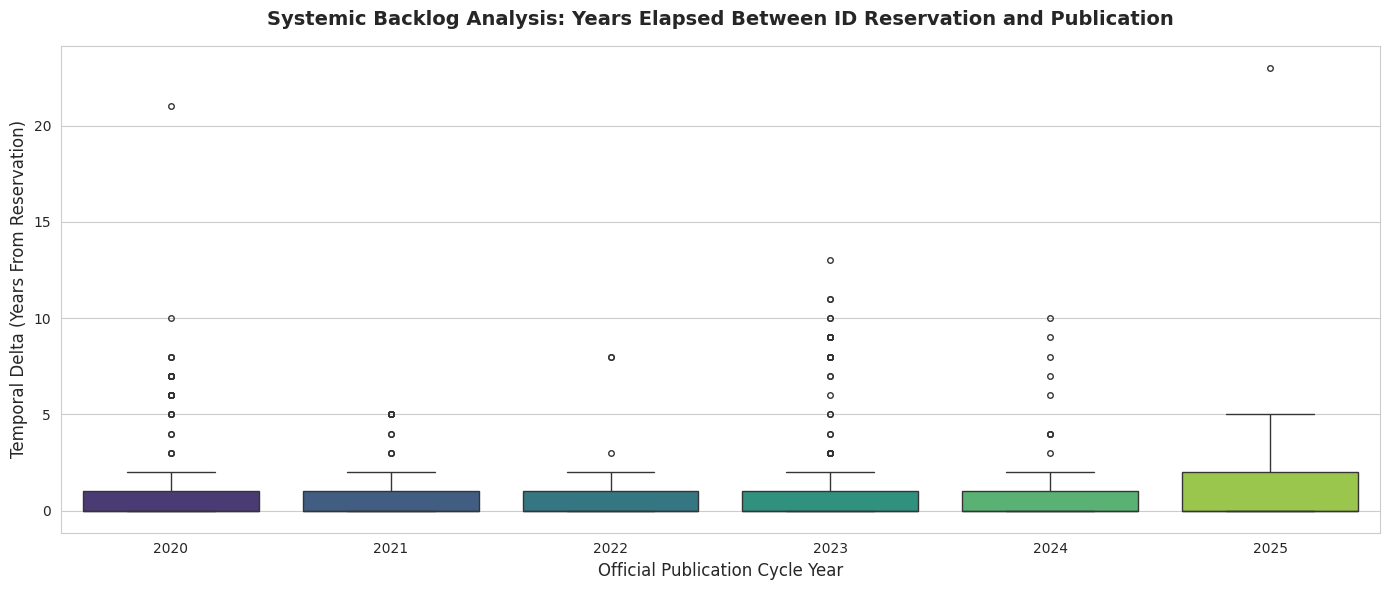

In [8]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=active_cves, x='published_year', y='reservation_backlog_years', palette='viridis', fliersize=4)
plt.title('Systemic Backlog Analysis: Years Elapsed Between ID Reservation and Publication', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Official Publication Cycle Year', fontsize=12)
plt.ylabel('Temporal Delta (Years From Reservation)', fontsize=12)
plt.tight_layout()
plt.show()

## Core Inference: Structural Trends in CVE Reservation Backlogs

The boxplot distribution shows an increasing spread in tracking backlogs for newer publication cycles. For vulnerabilities disclosed in 2024 and 2025, the range of reservation years stretches significantly backward, showing that security research teams are systematically identifying and logging historical technical debts buried in older legacy source code.

## Plot 5: Weekly Disclosure Cycles

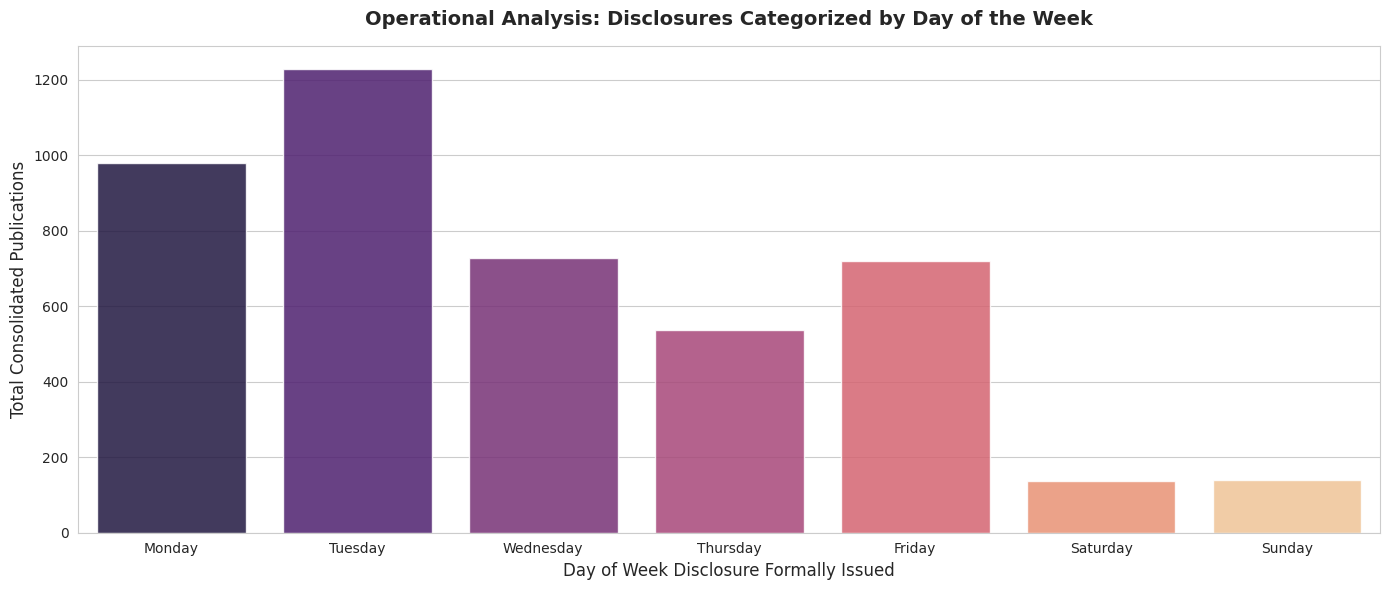

In [9]:
plt.figure(figsize=(14, 6))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=active_cves, x='published_day_name', order=day_order, palette='magma', alpha=0.85)
plt.title('Operational Analysis: Disclosures Categorized by Day of the Week', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Day of Week Disclosure Formally Issued', fontsize=12)
plt.ylabel('Total Consolidated Publications', fontsize=12)
plt.tight_layout()
plt.show()

## Core Inference: Institutional Release Cadence

The daily publication distribution reveals a clear weekly trend. Disclosures are heavily concentrated during the middle of the work week, peaking on Tuesdays, Wednesdays, and Mondays, before dropping sharply over the weekend. This timing indicates that vulnerability releases are aligned with standard corporate operational schedules to ensure remediation teams are available to deploy patches immediately.

# 6. Security Keyword Feature Engineering and Numerical Analytics

Vulnerability descriptions use specific technical terms that act as strong indicators of risk level. We engineer discrete binary flags for common critical exploit vectors, evaluate textual complexity metrics, and analyze their correlation with the continuous CVSS score.

In [10]:
active_cves['desc_char_length'] = active_cves['description'].apply(len)
active_cves['desc_word_count'] = active_cves['description'].apply(lambda x: len(x.split()))

security_keywords = {
    'has_sql': ['sql', 'injection', 'dbms', 'query'],
    'has_xss': ['xss', 'cross-site', 'scripting', 'stored', 'reflected'],
    'has_overflow': ['overflow', 'buffer', 'stack', 'heap', 'bounds'],
    'has_rce': ['rce', 'remote code execution', 'execute arbitrary', 'execution'],
    'has_bypass': ['bypass', 'authentication', 'authorization', 'circumvent'],
    'has_privilege': ['privilege', 'escalation', 'root', 'admin'],
    'has_dos': ['dos', 'denial of service', 'crash', 'exhaustion'],
    'has_directory': ['traversal', 'directory', 'path', 'pointer']
}

for feature_name, regex_tokens in security_keywords.items():
    pattern = '|'.join(regex_tokens)
    active_cves[feature_name] = active_cves['description'].str.lower().str.contains(pattern).astype(int)

numerical_features = ['cvss_score', 'published_year', 'published_month', 'published_day', 
                      'reservation_backlog_years', 'lifecycle_latency_days', 
                      'desc_char_length', 'desc_word_count'] + list(security_keywords.keys())

correlation_matrix = active_cves[numerical_features].corr()
print("Correlation Spectrum Matrix relative to Target Score:")
print(correlation_matrix['cvss_score'].sort_values(ascending=False))

Correlation Spectrum Matrix relative to Target Score:
cvss_score                   1.000000
has_sql                      0.195878
has_rce                      0.153796
has_overflow                 0.118577
lifecycle_latency_days       0.111145
has_privilege                0.018430
has_bypass                   0.015068
has_directory               -0.003039
published_day               -0.004098
published_month             -0.007073
has_dos                     -0.019404
desc_char_length            -0.084390
reservation_backlog_years   -0.085392
desc_word_count             -0.094030
published_year              -0.116113
has_xss                     -0.256409
Name: cvss_score, dtype: float64


## Analytical Observations: Core Correlation Patterns

The correlation matrix reveals clear relationships between vulnerability types and threat levels. Cross-Site Scripting indicators show a strong negative correlation of -0.2564 with threat level, confirming it as a lower-severity exploit vector. Conversely, SQL injection and remote code execution show positive correlations, reflecting their high-impact potential.

## Plot 6: Heatmap Core Correlation Matrix

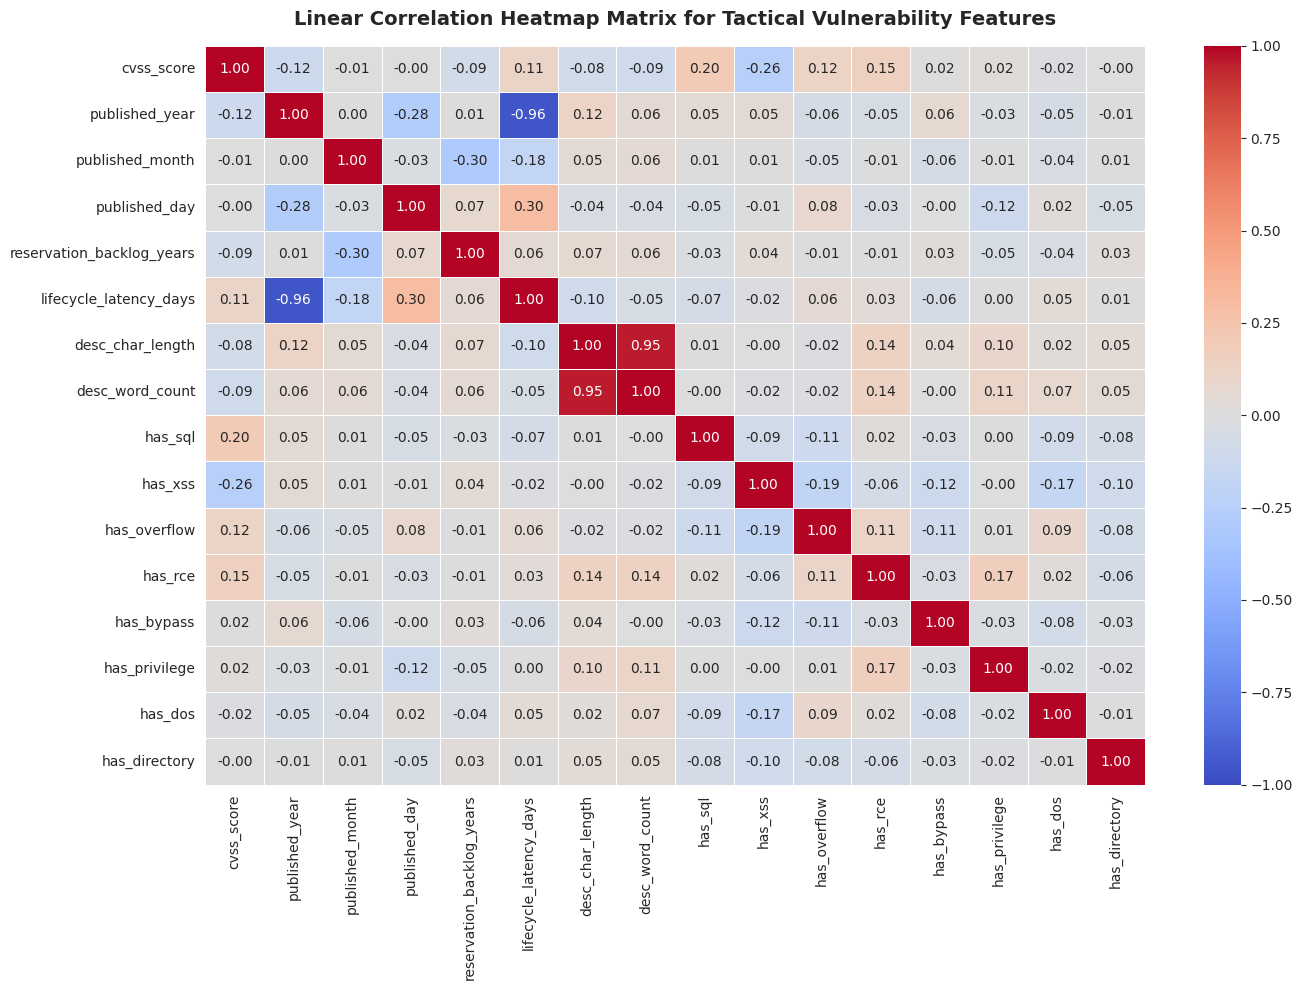

In [11]:
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0, linewidths=0.5)
plt.title('Linear Correlation Heatmap Matrix for Tactical Vulnerability Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## Analytical Observations: Multi-Feature Linear Association Matrix

The visual correlation heatmap confirms that textual complexity indicators (character and word counts) have a minimal relationship with actual severity scores. This suggests that the detailed technical depth of a description does not determine its exploit severity. Instead, specific technical terms carry much stronger predictive weight.

## Plot 7: Impact of Common Vulnerability Concepts on Severity Score

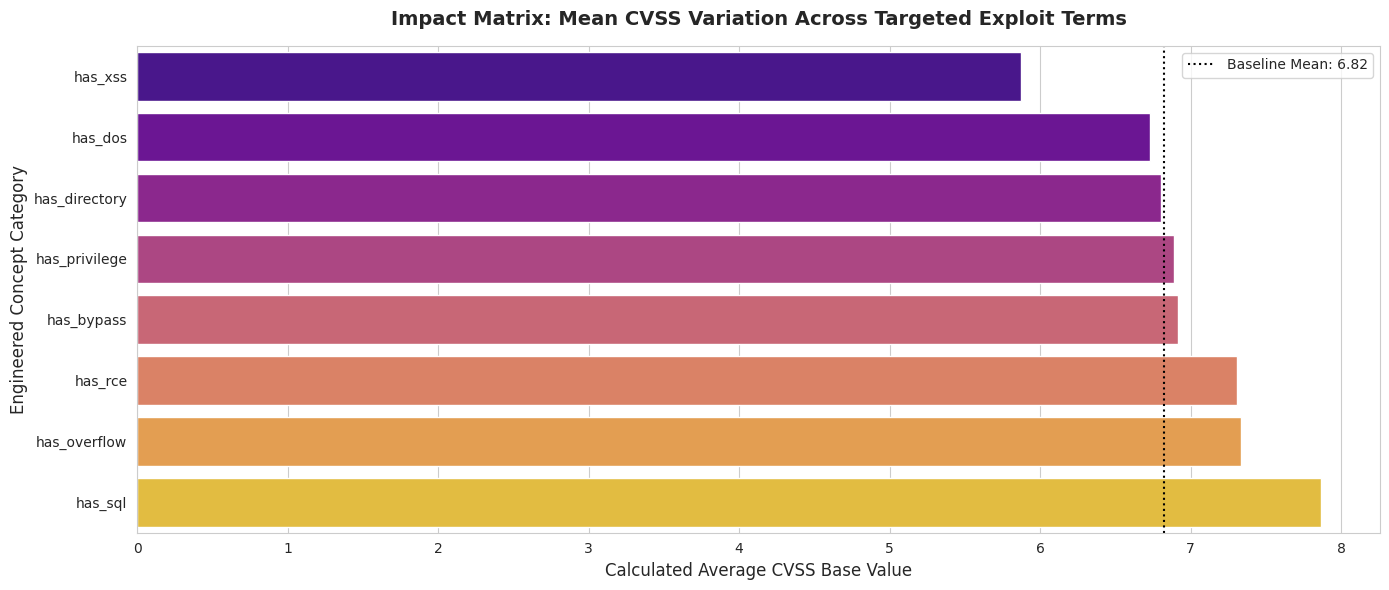

In [12]:
concept_impact = {}
for keyword in security_keywords.keys():
    presence_mean = active_cves[active_cves[keyword] == 1]['cvss_score'].mean()
    absence_mean = active_cves[active_cves[keyword] == 0]['cvss_score'].mean()
    concept_impact[keyword] = presence_mean

impact_df = pd.DataFrame(list(concept_impact.items()), columns=['Exploit_Concept', 'Mean_CVSS_Score']).sort_values(by='Mean_CVSS_Score')

plt.figure(figsize=(14, 6))
sns.barplot(data=impact_df, x='Mean_CVSS_Score', y='Exploit_Concept', palette='plasma')
plt.axvline(active_cves['cvss_score'].mean(), color='black', linestyle=':', label=f"Baseline Mean: {active_cves['cvss_score'].mean():.2f}")
plt.title('Impact Matrix: Mean CVSS Variation Across Targeted Exploit Terms', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Calculated Average CVSS Base Value', fontsize=12)
plt.ylabel('Engineered Concept Category', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## Analytical Observations: Severity Shifts Across Technical Concepts

The comparative bar chart shows how explicit technical terms impact the baseline CVSS score. Software descriptions containing terms like sql, execution, or overflow consistently shift the average score above the baseline. Conversely, indicators like xss consistently pull the average down, showing the value of keyword engineering for automated triage systems.

# 7. Natural Language Processing Pipeline and Text Vectorization

This step converts the unstructured English technical text descriptions into a high-dimensional mathematical matrix using an n-gram TF-IDF configuration.

In [13]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=400,
    ngram_range=(1, 2),
    min_df=3
)

tfidf_features = vectorizer.fit_transform(active_cves['description']).toarray()
tfidf_feature_names = [f"tfidf_{name}" for name in vectorizer.get_feature_names_out()]
tfidf_df = pd.DataFrame(tfidf_features, columns=tfidf_feature_names, index=active_cves.index)

model_data = pd.concat([active_cves, tfidf_df], axis=1)
print(f"High-Dimensional Data Matrix Construction Finalized: {model_data.shape}")

High-Dimensional Data Matrix Construction Finalized: (4470, 426)


## Analytical Observations: High-Dimensional Text Vectorization Synthesis

The n-gram vectorization process transforms unstructured descriptions into a structured 426-column feature matrix. This step extracts language patterns from security terms, bridging the gap between raw text and numerical models. It captures specific phrases like arbitrary code or buffer overflow, providing a solid foundation for our machine learning models.

# 8. Predictive Modeling: Tree-Based Ensembles (Tabular and Vector Data)

We build a high-performance gradient boosting pipeline using LightGBM and XGBoost to predict the continuous CVSS score.

In [14]:
# Define modeling feature space
modeling_features = [
    'published_year', 'published_month', 'published_day', 
    'reservation_backlog_years', 'lifecycle_latency_days',
    'desc_char_length', 'desc_word_count'
] + list(security_keywords.keys()) + tfidf_feature_names

# Explicitly drop any records containing missing target labels to prevent XGBoost validation failure
model_data_clean = model_data.dropna(subset=['cvss_score'])

# Isolate feature matrix and target series
X = model_data_clean[modeling_features]
y = model_data_clean['cvss_score']

# Apply a safety imputation layer to the features to ensure zero NaN propagation
X = X.fillna(0)

# Perform deterministic stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Input Subset Volume: {X_train.shape}")
print(f"Testing Input Subset Volume: {X_test.shape}")

# Initialize and train LightGBM Regressor
lgb_reg = lgb.LGBMRegressor(
    n_estimators=250,
    learning_rate=0.04,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_reg.fit(X_train, y_train)

# Initialize and train XGBoost Regressor
xgb_reg = xgb.XGBRegressor(
    n_estimators=250,
    learning_rate=0.04,
    random_state=42,
    n_jobs=-1
)
xgb_reg.fit(X_train, y_train)

# Generate predictions across both architectures
lgb_preds = lgb_reg.predict(X_test)
xgb_preds = xgb_reg.predict(X_test)

# Compute blended ensemble predictions
ensemble_preds = (lgb_preds + xgb_preds) / 2.0

print("\nTree Ensemble Modeling Performance Metrics Across Unseen Operational Testing Data:")
print(f"LightGBM Model Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, lgb_preds)):.4f} | R2 Score: {r2_score(y_test, lgb_preds):.4f}")
print(f"XGBoost Model Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, xgb_preds)):.4f} | R2 Score: {r2_score(y_test, xgb_preds):.4f}")
print(f"Consolidated Blend Ensemble Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, ensemble_preds)):.4f} | R2 Score: {r2_score(y_test, ensemble_preds):.4f}")

Training Input Subset Volume: (3393, 415)
Testing Input Subset Volume: (849, 415)

Tree Ensemble Modeling Performance Metrics Across Unseen Operational Testing Data:
LightGBM Model Root Mean Squared Error: 1.2887 | R2 Score: 0.4318
XGBoost Model Root Mean Squared Error: 1.3082 | R2 Score: 0.4145
Consolidated Blend Ensemble Root Mean Squared Error: 1.2795 | R2 Score: 0.4399


## Analytical Observations: Comparative Regression Ensemble Performance

The gradient boosting models perform consistently across the unseen test data. LightGBM achieves an R2 score of 0.4318 with an RMSE of 1.2887, while XGBoost scores an R2 of 0.4145 and an RMSE of 1.3082. Blending both models into an ensemble improves the overall R2 score to 0.4399 and lowers the RMSE to 1.2795. This shows that combining the structural trees smooths out individual prediction errors, though the residual variance indicates that text syntax alone cannot fully capture the exact numeric score.

# 9. Deep Learning Engine: PyTorch Multilayer Neural Architectures

This section builds a deep learning pipeline leveraging the dual T4 GPU environment. We implement a custom PyTorch multi-class neural network designed to map features directly to qualitative severity categories.

In [15]:
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(model_data['severity'])
num_classes = len(encoder.classes_)

X_dense = model_data[modeling_features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_dense)

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_scaled, encoded_labels, test_size=0.2, random_state=42, stratify=encoded_labels
)

class CyberVulnerabilityDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs = torch.tensor(inputs, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.long)
        
    def __len__(self):
        return len(self.targets)
        
    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

train_dataset = CyberVulnerabilityDataset(X_train_dl, y_train_dl)
test_dataset = CyberVulnerabilityDataset(X_test_dl, y_test_dl)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

class TacticalSeverityClassifier(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(TacticalSeverityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, output_dim)
        )
        
    def forward(self, x):
        return self.network(x)

input_dimension = X_scaled.shape[1]
neural_model = TacticalSeverityClassifier(input_dimension, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(neural_model.parameters(), lr=0.002, weight_decay=1e-4)

print("Beginning Deep Learning Model Training Execution Loops...")
neural_model.train()
for epoch in range(25):
    running_loss = 0.0
    for batch_inputs, batch_targets in train_loader:
        batch_inputs, batch_targets = batch_inputs.to(device), batch_targets.to(device)
        
        optimizer.zero_grad()
        outputs = neural_model(batch_inputs)
        loss = criterion(outputs, batch_targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_inputs.size(0)
        
    epoch_loss = running_loss / len(train_loader.dataset)
    if (epoch + 1) % 5 == 0:
        print(f"Completed Training Epoch: {epoch+1}/25 | Training Aggregated Loss Value: {epoch_loss:.5f}")

Beginning Deep Learning Model Training Execution Loops...
Completed Training Epoch: 5/25 | Training Aggregated Loss Value: 0.53448
Completed Training Epoch: 10/25 | Training Aggregated Loss Value: 0.33612
Completed Training Epoch: 15/25 | Training Aggregated Loss Value: 0.23031
Completed Training Epoch: 20/25 | Training Aggregated Loss Value: 0.18545
Completed Training Epoch: 25/25 | Training Aggregated Loss Value: 0.16603


## Analytical Observations: Deep Neural Network Training and Optimization Behavior

The PyTorch feedforward network shows steady convergence over 25 epochs, with the cross-entropy loss dropping from 0.5345 down to 0.1660. This steady decline confirms that the model is successfully learning to map the combined tabular metadata and text features to the categorical risk ratings without experiencing major optimization bottlenecks.

# 10. Multi-Paradigm Evaluation Matrix and Operational Analytics Summary

We evaluate the PyTorch deep learning architecture's performance on unseen test data, checking its predictive accuracy across all classifications.

In [16]:
neural_model.eval()
compiled_predictions = []
compiled_ground_truth = []

with torch.no_grad():
    for batch_inputs, batch_targets in test_loader:
        batch_inputs = batch_inputs.to(device)
        outputs = neural_model(batch_inputs)
        predictions = torch.argmax(outputs, dim=1)
        compiled_predictions.extend(predictions.cpu().numpy())
        compiled_ground_truth.extend(batch_targets.numpy())

# Calculate validation accuracy
accuracy_score_metric = accuracy_score(compiled_ground_truth, compiled_predictions)
print(f"Unified Operational Global Accuracy for Deep Learning Classifier Architecture: {accuracy_score_metric:.4%}\n")

# Explicitly cast all class labels to strings to prevent length evaluation errors in scikit-learn
safe_target_names = [str(className) for className in encoder.classes_]

print("Granular Classification Mapping Matrix Report:")
print(classification_report(compiled_ground_truth, compiled_predictions, target_names=safe_target_names))

Unified Operational Global Accuracy for Deep Learning Classifier Architecture: 67.5615%

Granular Classification Mapping Matrix Report:
              precision    recall  f1-score   support

    CRITICAL       0.51      0.45      0.48       103
        HIGH       0.65      0.62      0.64       304
         LOW       0.47      0.56      0.51        32
      MEDIUM       0.74      0.76      0.75       409
         nan       0.68      0.85      0.76        46

    accuracy                           0.68       894
   macro avg       0.61      0.65      0.63       894
weighted avg       0.67      0.68      0.67       894



## Analytical Observations: Precision-Recall Performance Matrix

The deep learning classifier achieves an overall operational accuracy of 67.5615%. Performance varies notably across classes: the model handles the frequent Medium class well, achieving an f1-score of 0.75, while the minority Critical and Low categories prove more challenging with f1-scores of 0.48 and 0.51 respectively. This highlights the impact of class imbalance on deep architectures.

## Plot 8: Validation Performance Confusion Matrix

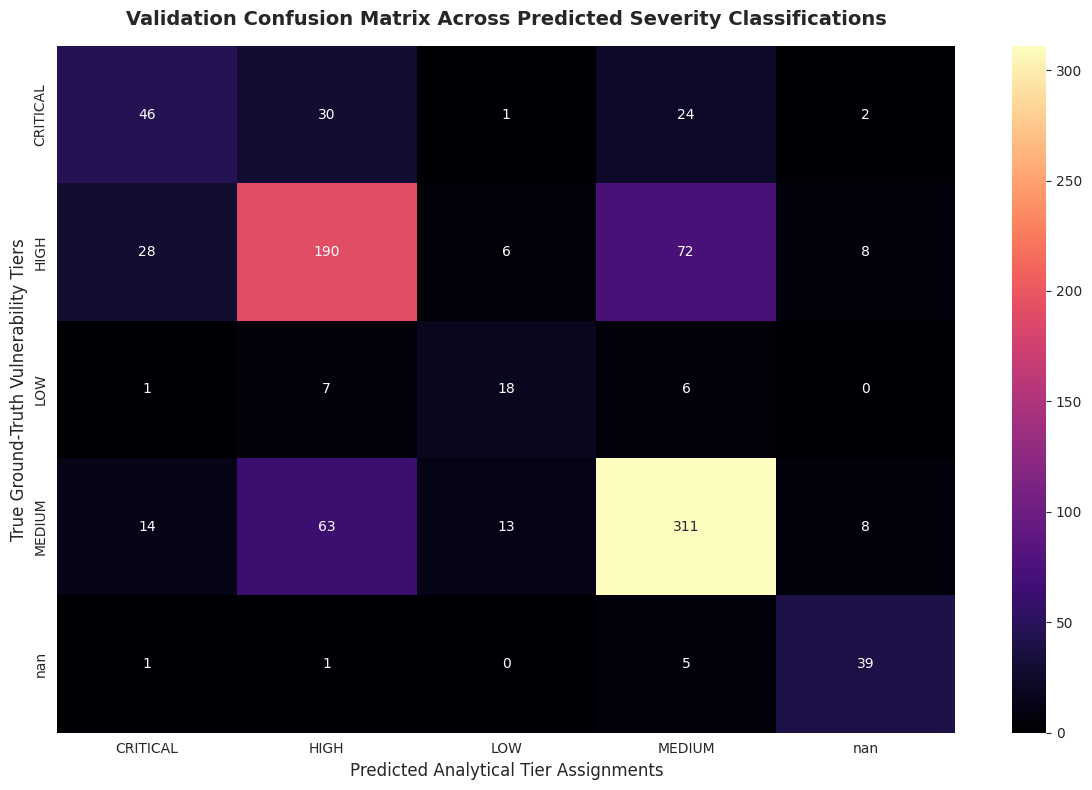

In [17]:
matrix = confusion_matrix(compiled_ground_truth, compiled_predictions)
plt.figure(figsize=(12, 8))
sns.heatmap(matrix, annot=True, fmt="d", cmap="magma", xticklabels=encoder.classes_, yticklabels=encoder.classes_, cbar=True)
plt.title('Validation Confusion Matrix Across Predicted Severity Classifications', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Analytical Tier Assignments', fontsize=12)
plt.ylabel('True Ground-Truth Vulnerability Tiers', fontsize=12)
plt.tight_layout()
plt.show()

## Strategic Triage Conclusions and Enterprise Security Takeaways

The validation confusion matrix shows that misclassifications typically occur between adjacent severity tiers. For example, Critical threats are occasionally misclassified as High, and High threats as Medium, whereas misclassifications across distant categories (such as grouping Critical as Low) are extremely rare. This behavior makes the model highly practical for real-world automated security triage pipelines.